In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    # macOS
else:
    plt.rcParams['font.family'] = 'NanumGothic'     # 리눅스나 colab 등

plt.rcParams['axes.unicode_minus'] = False  # 마이너스 부호 깨짐 방지

In [3]:
rename_dict = {
    "일시": "날짜",
    "평균기온(°C)": "평균 기온",
    "최저기온(°C)": "최저 기온",
    "최고기온(°C)": "최고 기온",
    "일강수량(mm)": "강수량"
}

recent = pd.read_csv("../weather_csv/weather_data1.csv", encoding="cp949").rename(columns=rename_dict)
past = pd.read_csv("../weather_csv/weather_past_data1.csv", encoding="cp949").rename(columns=rename_dict)

df = pd.concat([recent, past], ignore_index=True)
df = df[["날짜", "평균 기온", "최저 기온", "최고 기온", "강수량"]]
df["날짜"] = pd.to_datetime(df["날짜"])
df["평균 기온"] = pd.to_numeric(df["평균 기온"], errors="coerce")
df["최저 기온"] = pd.to_numeric(df["최저 기온"], errors="coerce")
df["최고 기온"] = pd.to_numeric(df["최고 기온"], errors="coerce")
df["강수량"] = pd.to_numeric(df["강수량"], errors="coerce").fillna(0)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3653 entries, 0 to 3652
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   날짜      3653 non-null   datetime64[ns]
 1   평균 기온   3653 non-null   float64       
 2   최저 기온   3652 non-null   float64       
 3   최고 기온   3653 non-null   float64       
 4   강수량     3653 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 142.8 KB


In [5]:
solar_terms = {
    "입춘": "02-04", "우수": "02-19", "경칩": "03-05", "춘분": "03-20", "청명": "04-04", "곡우": "04-20",
    "입하": "05-05", "소만": "05-21", "망종": "06-05", "하지": "06-21", "소서": "07-07", "대서": "07-22",
    "입추": "08-07", "처서": "08-23", "백로": "09-07", "추분": "09-23", "한로": "10-08", "상강": "10-23",
    "입동": "11-07", "소설": "11-22", "대설": "12-07", "동지": "12-22", "소한": "01-05", "대한": "01-20"
}

In [6]:
from datetime import datetime, timedelta

# 날짜 타입 변환
df['날짜'] = pd.to_datetime(df['날짜'])

# 연도 및 월-일 컬럼 생성
df['연도'] = df['날짜'].dt.year
df['월일'] = df['날짜'].dt.strftime('%m-%d')

# 절기 매핑용 함수 (±7일 범위)
def get_solar_term(date):
    for term, day in solar_terms.items():
        solar_date = datetime(date.year, int(day[:2]), int(day[3:]))
        if abs((solar_date - date).days) <= 7:
            return term
    return None

# 절기 컬럼 추가
df['절기'] = df['날짜'].apply(get_solar_term)

# 절기가 없는 행 제거
df = df.dropna(subset=['절기'])

In [7]:
df

,날짜,평균 기온,최저 기온,최고 기온,강수량,연도,월일,절기
0,2020-01-01,-2.2,-6.5,0.3,0.1,2020,01-01,소한
1,2020-01-02,1.0,-0.7,3.8,0.0,2020,01-02,소한
2,2020-01-03,-0.1,-3.4,4.6,0.0,2020,01-03,소한
3,2020-01-04,1.2,-2.8,6.1,0.0,2020,01-04,소한
4,2020-01-05,1.3,-3.2,6.6,0.0,2020,01-05,소한
...,...,...,...,...,...,...,...,...
3646,1999-12-25,-3.0,-4.9,-0.1,0.0,1999,12-25,동지
3647,1999-12-26,-3.3,-8.1,1.8,0.0,1999,12-26,동지
3648,1999-12-27,0.7,-4.5,5.9,0.0,1999,12-27,동지
3649,1999-12-28,3.4,-0.4,6.6,1.3,1999,12-28,동지


In [8]:
# 절기의 올바른 순서 정의
solar_term_order = [
    "소한", "대한", "입춘", "우수", "경칩", "춘분", "청명", "곡우", 
    "입하", "소만", "망종", "하지", "소서", "대서", 
    "입추", "처서", "백로", "추분", "한로", "상강", 
    "입동", "소설", "대설", "동지"
]

# 절기를 범주형 변수로 설정
df['절기'] = pd.Categorical(df['절기'], categories=solar_term_order, ordered=True)

In [9]:
# 기준(1995 ~ 1999) 절기별 평균/표준편차 계산
# 기준 연도 필터링
baseline = df[df['연도'].between(1995, 1999)]

# 절기별 기준 평균 및 표준편차
baseline_stats = baseline.groupby('절기')['평균 기온'].agg(['mean', 'std']).reset_index()
baseline_stats.columns = ['절기', '기준_평균', '기준_STD']

C:\Users\Playdata\AppData\Local\Temp\ipykernel_13392\3688293559.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  baseline_stats = baseline.groupby('절기')['평균 기온'].agg(['mean', 'std']).reset_index()


In [10]:
# 이상기온 여부 계산 (2020 ~ 2024)
# 분석 대상 필터링
target = df[df['연도'].between(2020, 2024)].copy()

# 기준값 merge
target = target.merge(baseline_stats, on='절기', how='left')

# 이상기온 여부 판별 (±1.5 * std 이상 벗어난 경우)
target['이상기온'] = abs(target['평균 기온'] - target['기준_평균']) > 1.5 * target['기준_STD']

C:\Users\Playdata\AppData\Local\Temp\ipykernel_13392\3300519820.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = target.groupby(['연도', '절기'])['이상기온'].sum().reset_index()


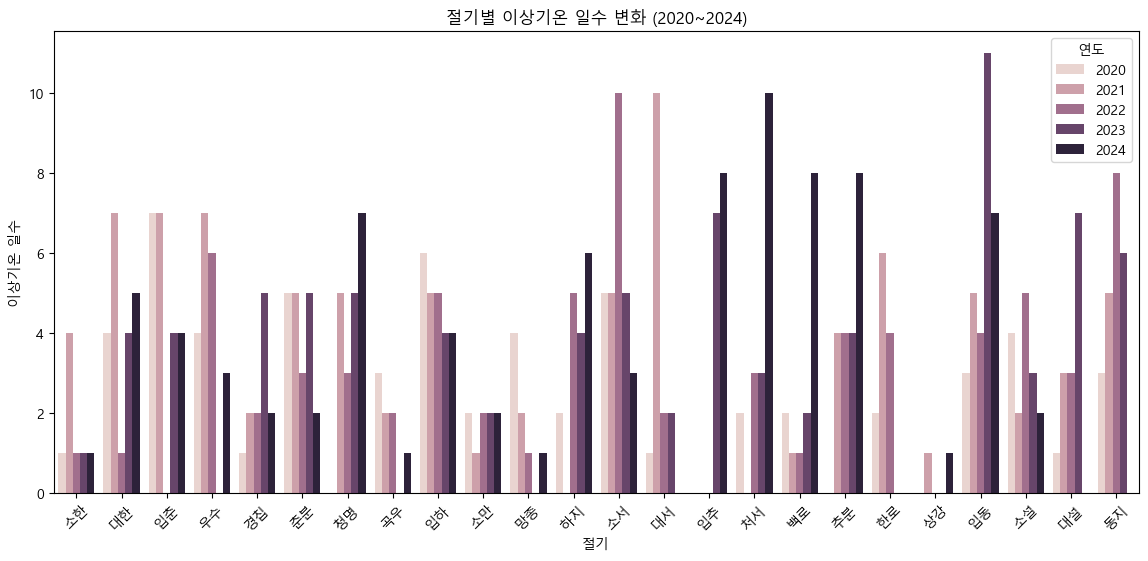

In [11]:
# 절기별 이상기온 일수 집계 및 시각화
# 절기별 이상기온 일수 카운트
summary = target.groupby(['연도', '절기'])['이상기온'].sum().reset_index()

# 시각화
plt.figure(figsize=(14, 6))
sns.barplot(data=summary, x='절기', y='이상기온', hue='연도')
plt.title('절기별 이상기온 일수 변화 (2020~2024)')
plt.xticks(rotation=45)
plt.ylabel("이상기온 일수")
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_13392\1847841063.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_temp_by_period = df_grouped.groupby(['기간', '절기'])['평균 기온'].mean().reset_index()


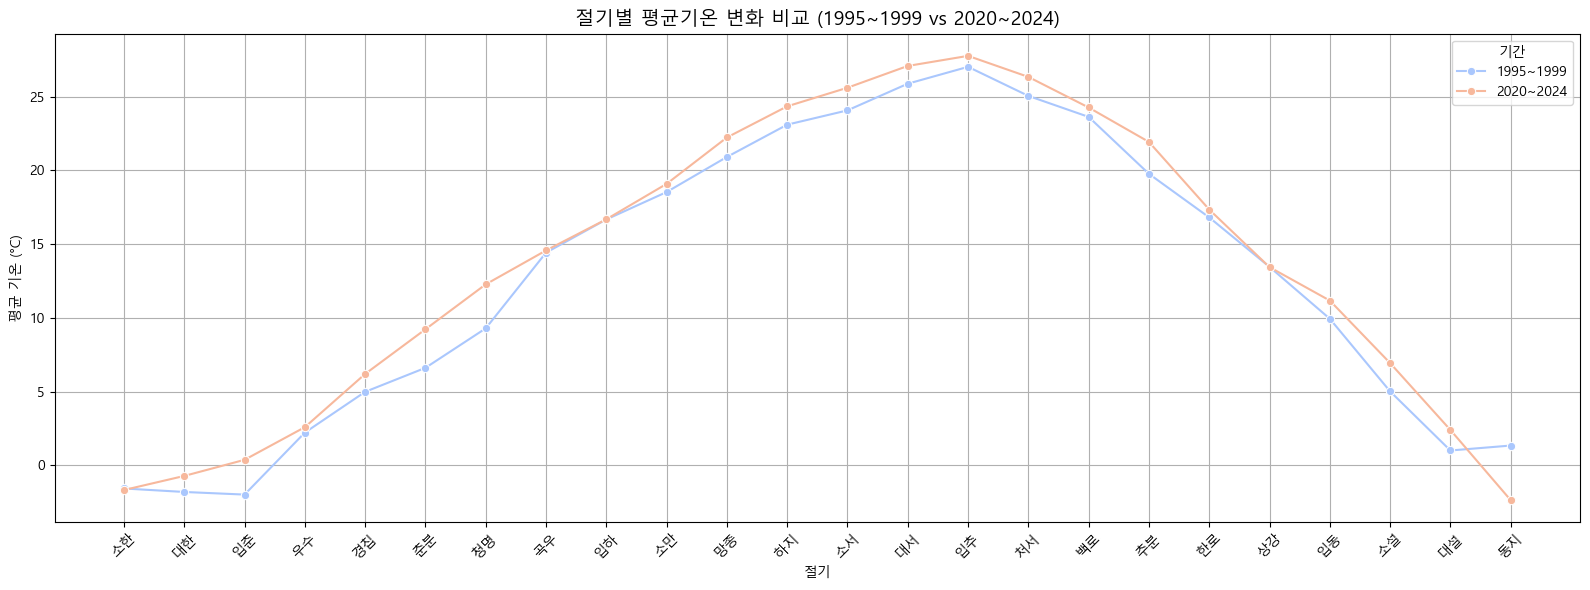

In [12]:
# 절기별 평균기온의 연도별 변화 추이
# -> 기온이 꾸준히 상승하는 절기 확인
# 그룹 라벨 생성: 1995~1999 → '1995~1999', 2020~2024 → '2020~2024'
def map_period(year):
    if 1995 <= year <= 1999:
        return '1995~1999'
    elif 2020 <= year <= 2024:
        return '2020~2024'
    else:
        return None

df['기간'] = df['연도'].apply(map_period)
df_grouped = df[df['기간'].notnull()]  # 필요한 기간만 필터링

# 절기별, 기간별 평균기온 계산
avg_temp_by_period = df_grouped.groupby(['기간', '절기'])['평균 기온'].mean().reset_index()

# 시각화
plt.figure(figsize=(16, 6))
sns.lineplot(data=avg_temp_by_period, x='절기', y='평균 기온', hue='기간', marker='o', palette='coolwarm')
plt.title('절기별 평균기온 변화 비교 (1995~1999 vs 2020~2024)', fontsize=14)
plt.ylabel('평균 기온 (°C)')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\Playdata\AppData\Local\Temp\ipykernel_13392\2778311945.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_temp_by_term = df[df['연도'].between(2020, 2024)].groupby(['연도', '절기'])['평균 기온'].mean().reset_index()


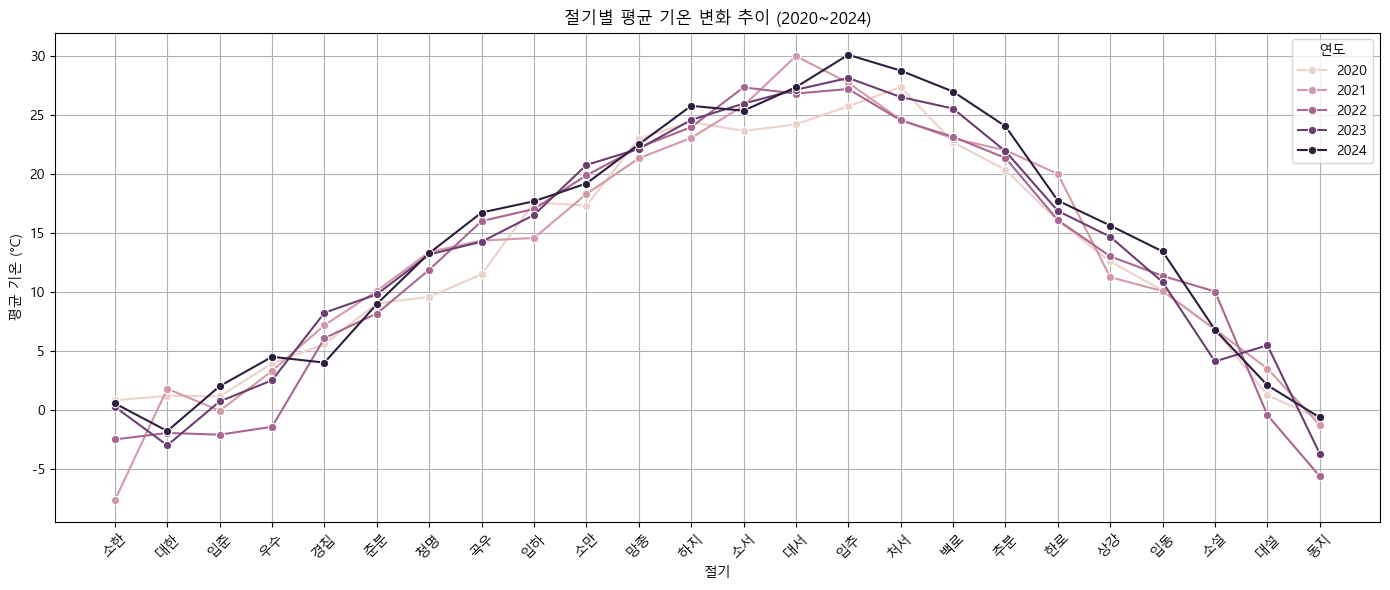

In [13]:
# 절기별 평균기온의 연도별 변화 추이
avg_temp_by_term = df[df['연도'].between(2020, 2024)].groupby(['연도', '절기'])['평균 기온'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=avg_temp_by_term, x='절기', y='평균 기온', hue='연도', marker='o')
plt.title('절기별 평균 기온 변화 추이 (2020~2024)')
plt.xticks(rotation=45)
plt.ylabel('평균 기온 (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()